# Kenya Maize Price Tracker
**Author:** Faith Njoroge  
**Dataset:** WFP Kenya Food Prices (2006–2025)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

## Objective
Analyze retail maize price trends across Kenyan regions and seasons 
to uncover patterns that can help farmers make better selling decisions.

## Key Questions
1. How have maize prices changed over time nationally?
2. Which regions have the highest and lowest prices?
3. Which months are cheapest and most expensive to sell?

In [137]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [138]:
#load dataset
df = pd.read_csv('../data/wfp_food_prices_ken.csv')
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
3,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Potatoes (Irish),148,50 KG,actual,Wholesale,KES,1249.99,17.39


In [139]:
print(f"rows: {df.shape[0]}")
print(f"columns: {df.shape[1]}")

rows: 19040
columns: 16


In [140]:
#column names and datatytpes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19040 entries, 0 to 19039
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          19040 non-null  object 
 1   admin1        18990 non-null  object 
 2   admin2        18990 non-null  object 
 3   market        19040 non-null  object 
 4   market_id     19040 non-null  int64  
 5   latitude      18990 non-null  float64
 6   longitude     18990 non-null  float64
 7   category      19040 non-null  object 
 8   commodity     19040 non-null  object 
 9   commodity_id  19040 non-null  int64  
 10  unit          19040 non-null  object 
 11  priceflag     19040 non-null  object 
 12  pricetype     19040 non-null  object 
 13  currency      19040 non-null  object 
 14  price         19040 non-null  float64
 15  usdprice      19040 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 2.3+ MB


In [141]:
#missing values
df.isnull().sum()

date             0
admin1          50
admin2          50
market           0
market_id        0
latitude        50
longitude       50
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
dtype: int64

In [142]:
#filter commodity
df['commodity'].unique()


array(['Maize (white)', 'Beans', 'Beans (dry)', 'Potatoes (Irish)',
       'Maize', 'Bread', 'Sorghum', 'Milk (cow, pasteurized)',
       'Oil (vegetable)', 'Fuel (diesel)', 'Fuel (kerosene)',
       'Fuel (petrol-gasoline)', 'Maize flour', 'Meat (beef)',
       'Meat (goat)', 'Cooking fat', 'Bananas', 'Kale', 'Onions (red)',
       'Tomatoes', 'Beans (kidney)', 'Beans (rosecoco)', 'Onions (dry)',
       'Spinach', 'Potatoes (Irish, white)', 'Cabbage', 'Rice (aromatic)',
       'Sorghum (red)', 'Cowpea leaves', 'Maize (white, dry)',
       'Beans (mung)', 'Beans (yellow)', 'Cowpeas',
       'Potatoes (Irish, red)', 'Fish (omena, dry)', 'Beans (dolichos)',
       'Millet (finger)', 'Sorghum (white)', 'Rice (imported, Pakistan)',
       'Maize flour (white)', 'Wheat flour', 'Sugar',
       'Oil (vegetable, fortified)', 'Cowpeas (dry)', 'Salt',
       'Pigeon peas (dry)', 'Rice', 'Milk (UHT)', 'Meat (camel)',
       'Milk (cow, fresh)', 'Milk (camel, fresh)'], dtype=object)

In [143]:
#keep only maize types
maize_types = ['Maize', 'Maize (white)', 'Maize (white, dry)']
df_maize = df[df['commodity'].isin(maize_types) & (df['pricetype'] == 'Retail')]
df_maize.shape

(1442, 16)

In [144]:
# Show all rows where price is suspiciously low (below 10 KES/kg)
outliers_low = df_maize[df_maize['price'] < 10]
print(f"Rows with price below 10 KES: {len(outliers_low)}")
print(outliers_low[['date', 'admin1', 'commodity', 'price', 'unit']])

Rows with price below 10 KES: 6
            date   admin1      commodity  price unit
301   2007-03-15  Eastern  Maize (white)    8.0   KG
347   2007-05-15  Eastern  Maize (white)    8.0   KG
409   2007-08-15  Eastern  Maize (white)    9.0   KG
451   2007-10-15  Eastern  Maize (white)    9.0   KG
475   2007-11-15  Eastern  Maize (white)    9.0   KG
1202  2010-06-15  Eastern  Maize (white)    6.0   KG


In [145]:
# Remove low price outliers — data entry errors (below 10 KES/kg)
df_maize = df_maize[df_maize['price'] >= 10]

# Confirm removal
print(f"Rows after removing outliers: {df_maize.shape[0]}")


Rows after removing outliers: 1436


In [146]:
#check and drop missing values
df_maize.isnull().sum()
df_maize=df_maize.dropna(subset=['admin1'])
df_maize.shape

(1386, 16)

In [147]:
df_maize.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
3,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.0,0.24
6,2006-01-15,Eastern,Marsabit,Marsabit,190,2.33,37.98,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,21.0,0.29
12,2006-01-15,North Eastern,Mandera,Mandera,189,3.94,41.86,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,30.0,0.42
24,2006-02-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,18.0,0.25
26,2006-02-15,Eastern,Marsabit,Marsabit,190,2.33,37.98,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,22.0,0.31


In [148]:
#fix date datatype
df_maize['date'] = pd.to_datetime(df_maize['date'])

#extract yeart and month
df_maize['year'] = df_maize['date'].dt.year
df_maize['month'] = df_maize['date'].dt.month

#preview
df_maize[['date','year','month']].head()

,date,year,month
3,2006-01-15,2006,1
6,2006-01-15,2006,1
12,2006-01-15,2006,1
24,2006-02-15,2006,2
26,2006-02-15,2006,2


In [149]:
#data summary
print(f"Date Range: {df_maize['date'].min()} to {df_maize['date'].max()}")
print(f"regions: {df_maize['admin1'].nunique()}")
print(f"regions included:")
print(df_maize['admin1'].unique())

Date Range: 2006-01-15 00:00:00 to 2025-11-15 00:00:00
regions: 5
regions included:
['Eastern' 'North Eastern' 'Rift Valley' 'Coast' 'Nairobi']


In [150]:
#EDA ANALYSIS
#average price per year
avg_price_year = df_maize.groupby('year')['price'].mean().reset_index()
print(avg_price_year)

    year      price
0   2006  23.714286
1   2007  23.052632
2   2008  31.730769
3   2009  40.530435
4   2010  36.908148
5   2011  49.393750
6   2012  62.802381
7   2013  60.087273
8   2014  54.099500
9   2015  50.210000
10  2016  47.565574
11  2017  61.043548
12  2018  50.868889
13  2019  54.716129
14  2020  56.417742
15  2021  49.055217
16  2022  48.697222
17  2023  82.235215
18  2024  76.263785
19  2025  71.157436


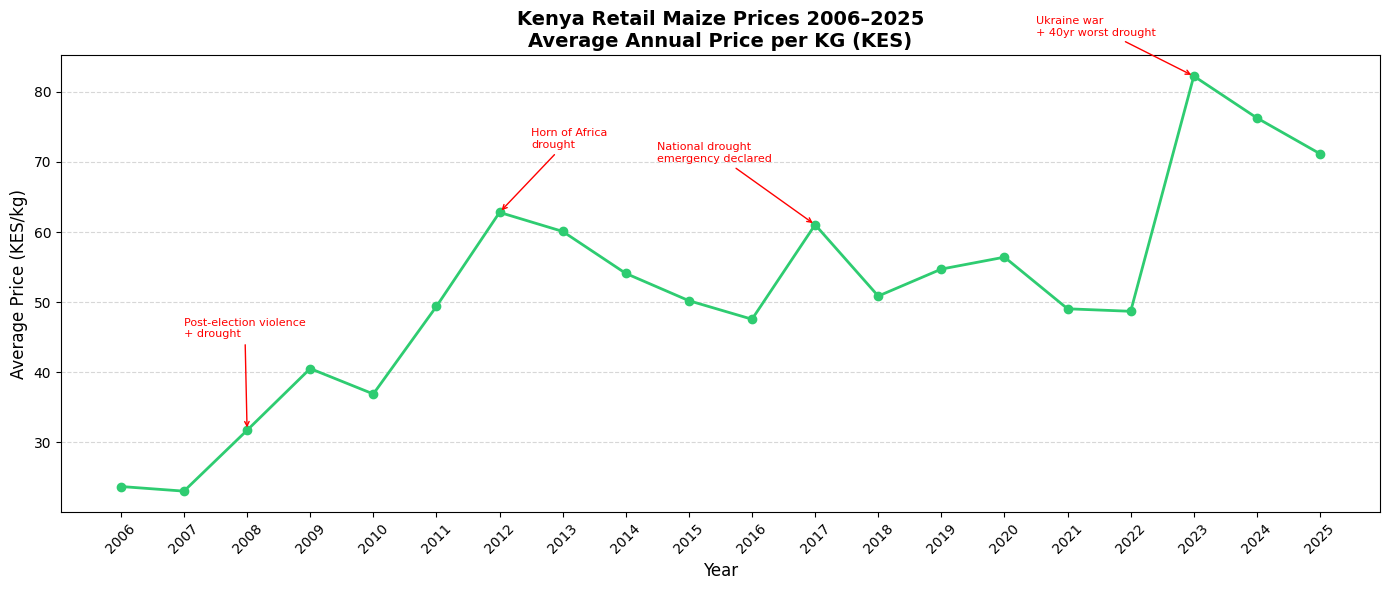

In [151]:
plt.figure(figsize=(14, 6))

plt.plot(avg_price_year['year'], avg_price_year['price'],
         marker='o',
         color='#2ecc71',
         linewidth=2,
         markersize=6)

# 2008-2009 spike
plt.annotate('Post-election violence\n+ drought',
             xy=(2008, 31.73),
             xytext=(2007, 45),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=8)

# 2011-2012 spike
plt.annotate('Horn of Africa\ndrought',
             xy=(2012, 62.80),
             xytext=(2012.5, 72),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=8)

# 2017 spike
plt.annotate('National drought\nemergency declared',
             xy=(2017, 61.04),
             xytext=(2014.5, 70),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=8)

# 2023 spike
plt.annotate('Ukraine war\n+ 40yr worst drought',
             xy=(2023, 82.23),
             xytext=(2020.5, 88),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=8)

plt.title('Kenya Retail Maize Prices 2006–2025\nAverage Annual Price per KG (KES)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (KES/kg)', fontsize=12)
plt.xticks(avg_price_year['year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/yearly_price_trend.png', dpi=150)
plt.show()

In [152]:
#avg price per region
avg_region_price = df_maize.groupby('admin1')['price'].mean().reset_index()
avg_region_price = avg_region_price.sort_values('price', ascending= False)
print(avg_region_price)

          admin1      price
3  North Eastern  68.542006
4    Rift Valley  64.718547
0          Coast  55.316053
2        Nairobi  49.520784
1        Eastern  47.662235


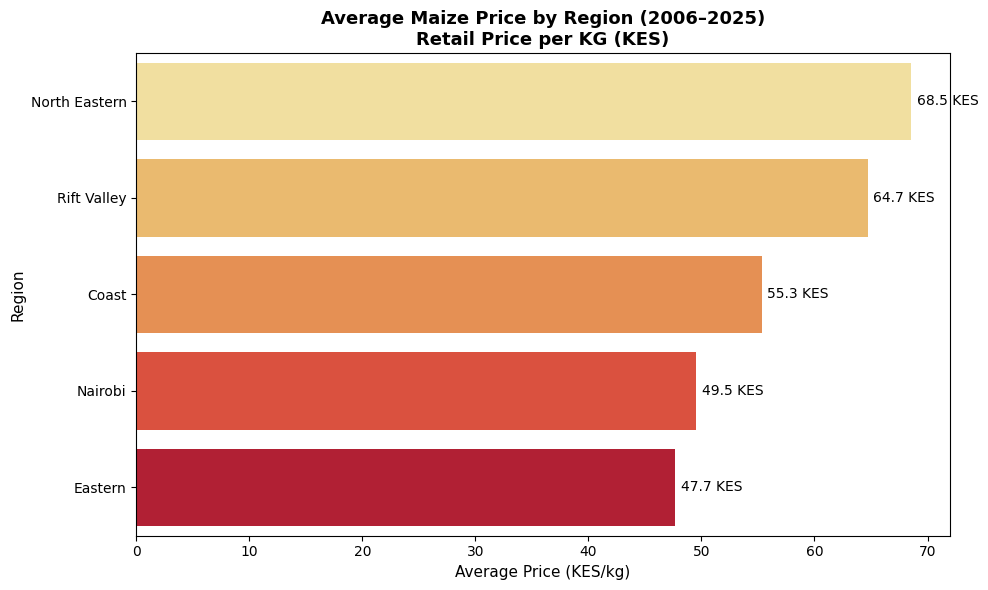

In [153]:
plt.figure(figsize=(10, 6))

# Use seaborn for a cleaner bar chart
sns.barplot(data=avg_region_price, 
            x='price', 
            y='admin1',
            hue='admin1',
            palette='YlOrRd',
           legend = False)

# Add value labels on each bar
for index, row in avg_region_price.iterrows():
    plt.text(row['price'] + 0.5, 
             list(avg_region_price['admin1']).index(row['admin1']),
             f"{row['price']:.1f} KES",
             va='center',
             fontsize=10)

plt.title('Average Maize Price by Region (2006–2025)\nRetail Price per KG (KES)',
          fontsize=13, fontweight='bold')
plt.xlabel('Average Price (KES/kg)', fontsize=11)
plt.ylabel('Region', fontsize=11)
plt.tight_layout()
plt.savefig('../data/regional_price_comparison.png', dpi=150)
plt.show()

In [154]:
# Average price per month across all years
monthly_avg = df_maize.groupby('month')['price'].mean().reset_index()

# Replace month numbers with month names so the chart is readable
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_avg['month_name'] = monthly_avg['month'].map(month_names)
monthly_avg = monthly_avg.sort_values('price', ascending = True)
print(monthly_avg)

    month      price month_name
1       2  49.600215        Feb
3       4  50.402073        Apr
0       1  51.972692        Jan
9      10  52.514886        Oct
10     11  54.213587        Nov
4       5  54.687558        May
6       7  55.785543        Jul
7       8  56.853933        Aug
8       9  66.833927        Sep
5       6  67.943315        Jun
11     12  71.047267        Dec
2       3  71.336159        Mar


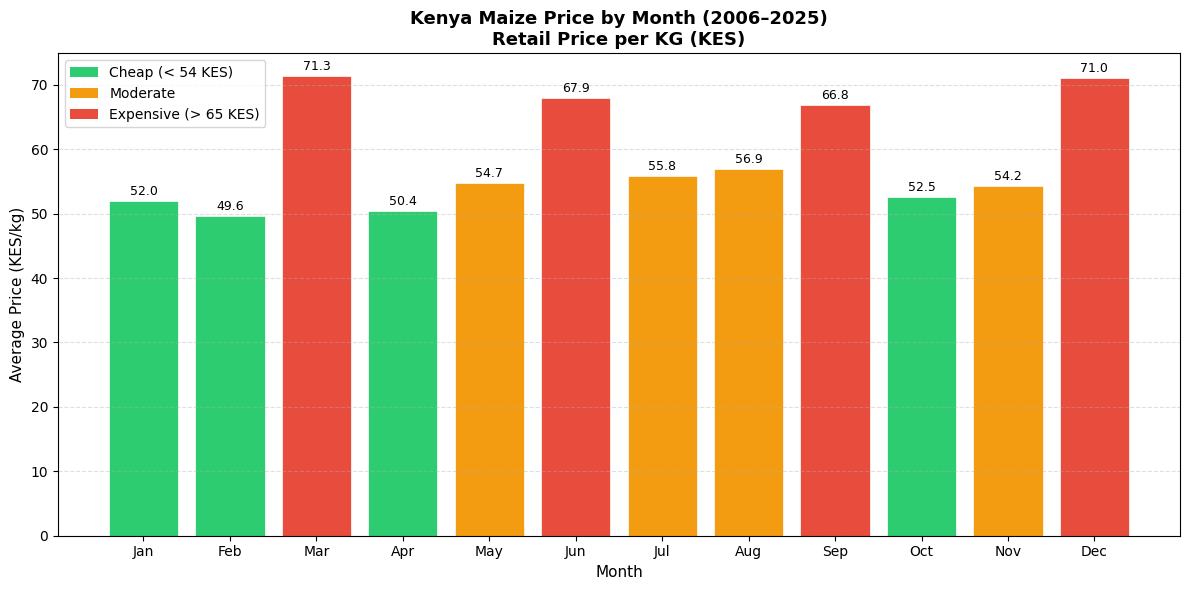

In [155]:
plt.figure(figsize=(12, 6))

# Use the correct month order
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Reorder the dataframe by month order
monthly_avg['month_name'] = pd.Categorical(monthly_avg['month_name'], 
                                            categories=month_order, 
                                            ordered=True)
monthly_avg = monthly_avg.sort_values('month_name')

# Color bars by price — green=cheap, red=expensive
colors = ['#2ecc71' if p < 54 else '#e74c3c' if p > 65 else '#f39c12' 
          for p in monthly_avg['price']]

bars = plt.bar(monthly_avg['month_name'], 
               monthly_avg['price'],
               color=colors,
               edgecolor='white',
               linewidth=0.5)

# Add value labels on top of each bar
for bar, price in zip(bars, monthly_avg['price']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{price:.1f}',
             ha='center',
             va='bottom',
             fontsize=9)

# Add a legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Cheap (< 54 KES)'),
                   Patch(facecolor='#f39c12', label='Moderate'),
                   Patch(facecolor='#e74c3c', label='Expensive (> 65 KES)')]
plt.legend(handles=legend_elements, loc='upper left')

plt.title('Kenya Maize Price by Month (2006–2025)\nRetail Price per KG (KES)',
          fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Average Price (KES/kg)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../data/monthly_price_pattern.png', dpi=150)
plt.show()


In [156]:
# Average price per year per region
regional_yearly = df_maize.groupby(['year', 'admin1'])['price'].mean().reset_index()

print(regional_yearly.head(10))


   year         admin1      price
0  2006        Eastern  20.500000
1  2006  North Eastern  26.000000
2  2006    Rift Valley  27.857143
3  2007        Eastern  16.444444
4  2007  North Eastern  29.000000
5  2007    Rift Valley  29.000000
6  2008        Eastern  28.000000
7  2008  North Eastern  33.666667
8  2008    Rift Valley  43.750000
9  2009        Eastern  39.208333


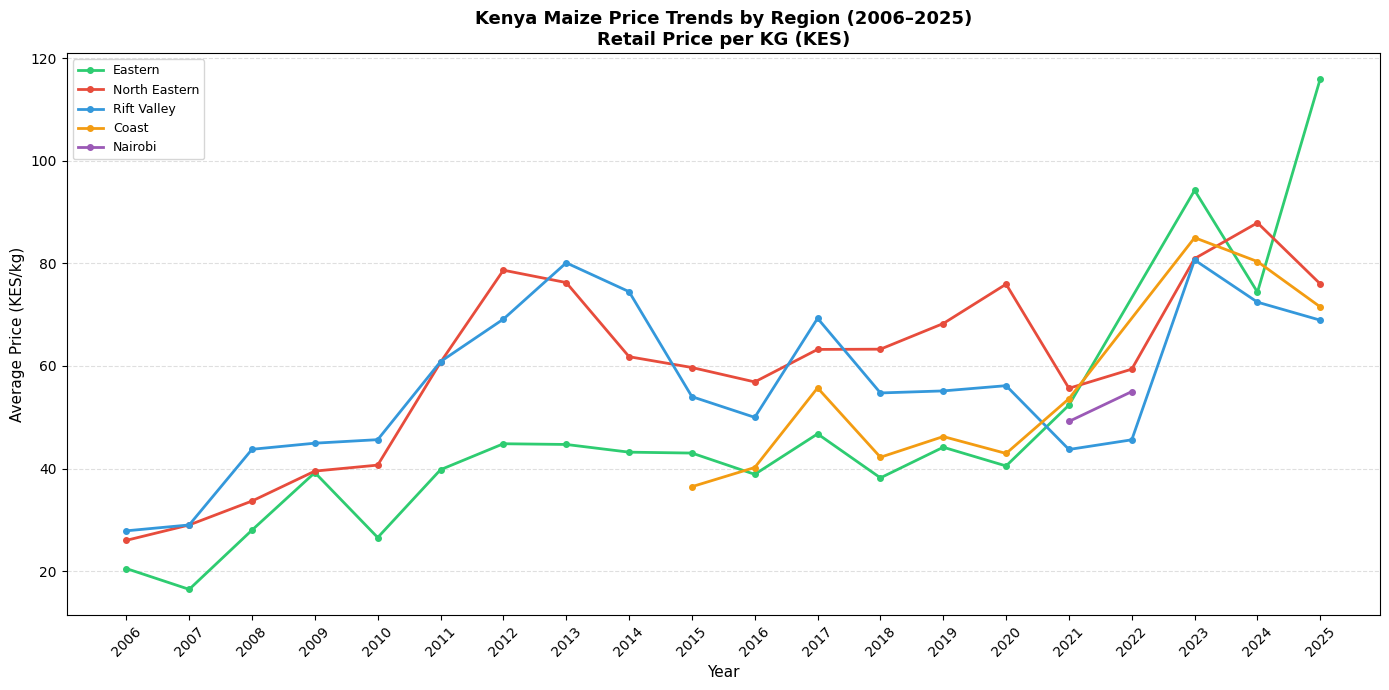

In [157]:
plt.figure(figsize=(14, 7))

# Get unique regions
regions = regional_yearly['admin1'].unique()

# Color palette — one color per region
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for i, region in enumerate(regions):
    region_data = regional_yearly[regional_yearly['admin1'] == region]
    plt.plot(region_data['year'], 
             region_data['price'],
             marker='o',
             linewidth=2,
             markersize=4,
             color=colors[i],
             label=region)

plt.title('Kenya Maize Price Trends by Region (2006–2025)\nRetail Price per KG (KES)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Average Price (KES/kg)', fontsize=11)
plt.xticks(regional_yearly['year'].unique(), rotation=45)
plt.legend(loc='upper left', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../data/regional_yearly_trends.png', dpi=150)
plt.show()

In [158]:
# Filter for Coast region only, sorted by year
coast_prices = regional_yearly[regional_yearly['admin1'] == 'Nairobi'].sort_values('year')
print(coast_prices)

    year   admin1      price
53  2021  Nairobi  49.178333
56  2022  Nairobi  55.000000


In [159]:
print("=" * 55)
print("KENYA MAIZE PRICE ANALYSIS — KEY FINDINGS")
print("=" * 55)

print(f"""
DATASET
-------
Period:     2006 – 2025
Regions:    {df_maize['admin1'].nunique()}
Records:    {df_maize.shape[0]:,}

PRICE OVERVIEW
--------------
Lowest avg price:   {df_maize['price'].min():.1f} KES/kg
Highest avg price:  {df_maize['price'].max():.1f} KES/kg
Overall average:    {df_maize['price'].mean():.1f} KES/kg

REGIONAL INSIGHTS
-----------------
Most expensive:  {avg_region_price.iloc[0]['admin1']} 
                 ({avg_region_price.iloc[0]['price']:.1f} KES/kg)
Cheapest:        {avg_region_price.iloc[-1]['admin1']} 
                 ({avg_region_price.iloc[-1]['price']:.1f} KES/kg)

SEASONAL INSIGHTS
-----------------
Cheapest month:   {monthly_avg.loc[monthly_avg['price'].idxmin(), 'month_name']} 
                  ({monthly_avg['price'].min():.1f} KES/kg)
Most exp. month:  {monthly_avg.loc[monthly_avg['price'].idxmax(), 'month_name']} 
                  ({monthly_avg['price'].max():.1f} KES/kg)

KEY EVENTS
----------
2008–09: Post-election violence + drought
2011–12: Horn of Africa drought
2017:    National drought emergency declared
2023:    Ukraine war + worst drought in 40 years

RECOMMENDATION FOR FARMERS
---------------------------
Avoid selling in Feb–Apr (harvest glut, lowest prices)
Best time to sell: Mar, Jun, Dec (30–40% price premium)
""")
print("=" * 55)


KENYA MAIZE PRICE ANALYSIS — KEY FINDINGS

DATASET
-------
Period:     2006 – 2025
Regions:    5
Records:    1,386

PRICE OVERVIEW
--------------
Lowest avg price:   12.0 KES/kg
Highest avg price:  150.0 KES/kg
Overall average:    61.1 KES/kg

REGIONAL INSIGHTS
-----------------
Most expensive:  North Eastern 
                 (68.5 KES/kg)
Cheapest:        Eastern 
                 (47.7 KES/kg)

SEASONAL INSIGHTS
-----------------
Cheapest month:   Feb 
                  (49.6 KES/kg)
Most exp. month:  Mar 
                  (71.3 KES/kg)

KEY EVENTS
----------
2008–09: Post-election violence + drought
2011–12: Horn of Africa drought
2017:    National drought emergency declared
2023:    Ukraine war + worst drought in 40 years

RECOMMENDATION FOR FARMERS
---------------------------
Avoid selling in Feb–Apr (harvest glut, lowest prices)
Best time to sell: Mar, Jun, Dec (30–40% price premium)

